# Why Do Some Film Genres Have the Highest IMDb Ratings?

### Research Question
**Why do certain genres consistently receive the highest IMDb ratings? What measurable factors (budget, country, director) might help explain these differences?**

### Dataset Source
Kaggle: *Movie and TV series data from Kinopoisk and IMDb*

We will explore:
- Rating distribution by genre
- Budgets vs ratings
- Countries associated with high-rated genres
- Directors contributing to top-rated genres



In [2]:
!pip install kagglehub pandas matplotlib numpy



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub, os

dataset_path = kagglehub.dataset_download("mostov/movie-and-tv-series-data-from-kinopoisk-and-imdb")
print("Downloaded path:", dataset_path)

csv_path = None
for root, _, files in os.walk(dataset_path):
    for f in files:
        if "imdb" in f.lower() and f.endswith(".csv"):
            csv_path = os.path.join(root, f)

print("Found file:", csv_path)

C:\Users\ivaik\PycharmProjects\JupyterProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded path: C:\Users\ivaik\.cache\kagglehub\datasets\mostov\movie-and-tv-series-data-from-kinopoisk-and-imdb\versions\1
Found file: C:\Users\ivaik\.cache\kagglehub\datasets\mostov\movie-and-tv-series-data-from-kinopoisk-and-imdb\versions\1\imdb_films.csv


### Copying the dataset into the `data/` project folder


In [4]:
import shutil

os.makedirs("data", exist_ok=True)
dest = "data/imdb_films.csv"
shutil.copy(csv_path, dest)

print("File copied to:", dest)

File copied to: data/imdb_films.csv


### Load and Clean Data



In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/imdb_films.csv")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Budget"] = pd.to_numeric(df["Budget"], errors="coerce")
df["Fees"] = pd.to_numeric(df["Fees"], errors="coerce")

df["primary_genre"] = df["Genres"].astype(str).str.split(",").str[0].str.strip()

df_clean = df.dropna(subset=["Rating", "Year"])

df_clean.head()


,Title,Year,Rating,Age Limit,Genres,Country,Director,Budget,Fees,Description,primary_genre
0,Побег из Шоушенка,1994,9.3,16+,"Epic, Period Drama, Prison Drama, Drama",United States,Frank Darabont,25000000,29333735,A banker convicted of uxoricide forms a friend...,Epic
1,Крёстный отец,1972,9.2,16+,"Epic, Gangster, Tragedy, Crime, Drama",United States,Francis Ford Coppola,6000000,250342198,The aging patriarch of an organized crime dyna...,Epic
2,Тёмный рыцарь,2008,9.0,14+,"Action Epic, Epic, Superhero, Tragedy, Action,...",United States,Christopher Nolan,185000000,1009057329,When a menace known as the Joker wreaks havoc ...,Action Epic
3,Крёстный отец 2,1974,9.0,16+,"Epic, Gangster, Tragedy, Crime, Drama",United States,Francis Ford Coppola,13000000,47983687,The early life and career of Vito Corleone in ...,Epic
4,12 рaзгневанных мужчин,1957,9.0,16+,"Legal Drama, Psychological Drama, Crime, Drama",United States,Sidney Lumet,350000,2945,The jury in a New York City murder trial is fr...,Legal Drama


 ###  Visualization 1: Distribution of IMDb Ratings


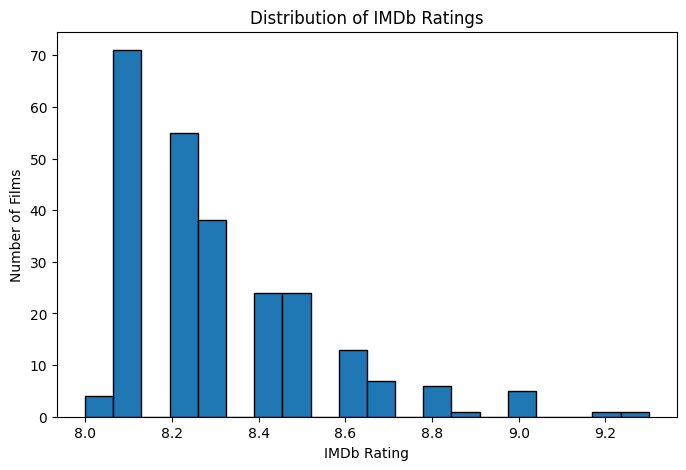

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["Rating"], bins=20, edgecolor="black")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Films")
plt.title("Distribution of IMDb Ratings")
plt.savefig("viz1_rating_dist.png", dpi=300)
plt.show()

### Visualization 2: Top Genres by Average Rating


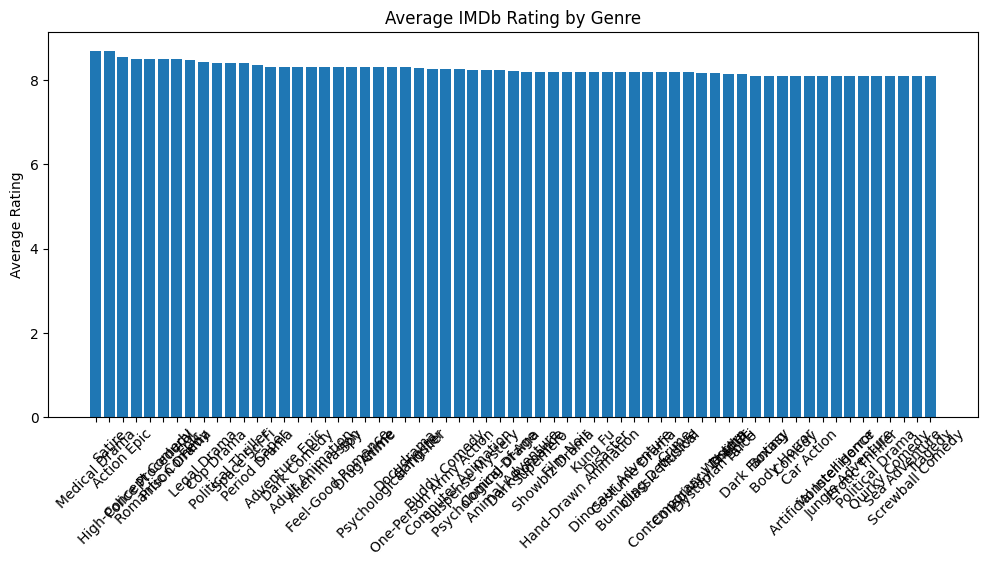

primary_genre
Medical Drama          8.700000
Satire                 8.700000
Action Epic            8.552381
High-Concept Comedy    8.500000
Police Procedural      8.500000
Name: Rating, dtype: float64

In [7]:
avg_rating = df_clean.groupby("primary_genre")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.bar(avg_rating.index, avg_rating.values)
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.title("Average IMDb Rating by Genre")
plt.savefig("viz2_avg_rating_genre.png", dpi=300)
plt.show()

avg_rating.head()


### Visualization 3: Average Budget by Genre
Does high rating correlate with higher budgets?

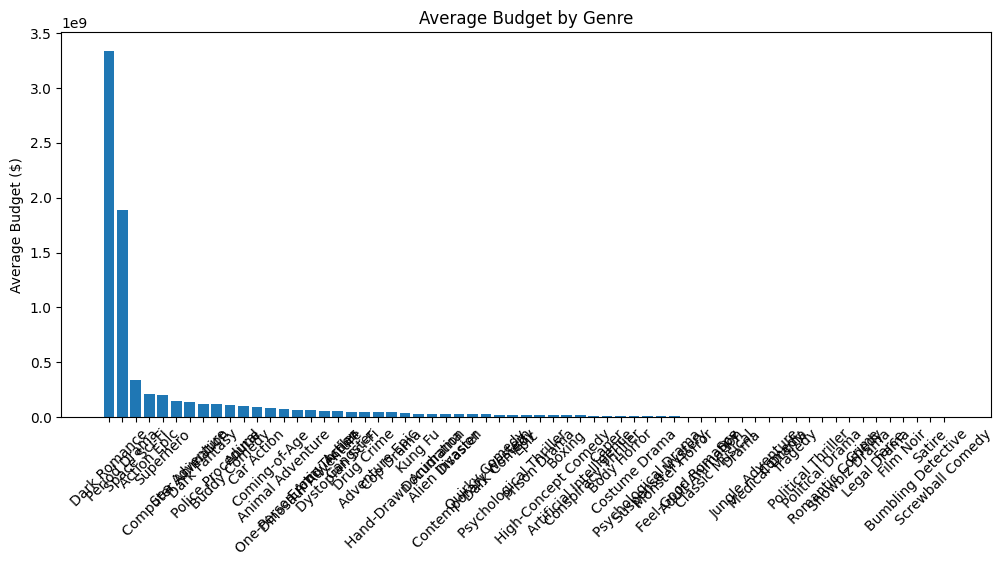

primary_genre
Dark Romance    3.340667e+09
Period Drama    1.892556e+09
Space Sci-Fi    3.385000e+08
Action Epic     2.154143e+08
Superhero       2.000000e+08
Name: Budget, dtype: float64

In [8]:
avg_budget = df_clean.groupby("primary_genre")["Budget"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
plt.bar(avg_budget.index, avg_budget.values)
plt.xticks(rotation=45)
plt.ylabel("Average Budget ($)")
plt.title("Average Budget by Genre")
plt.savefig("viz3_budget_genre.png", dpi=300)
plt.show()

avg_budget.head()

### Visualization 4: Ratings vs Budget (Correlation Plot)

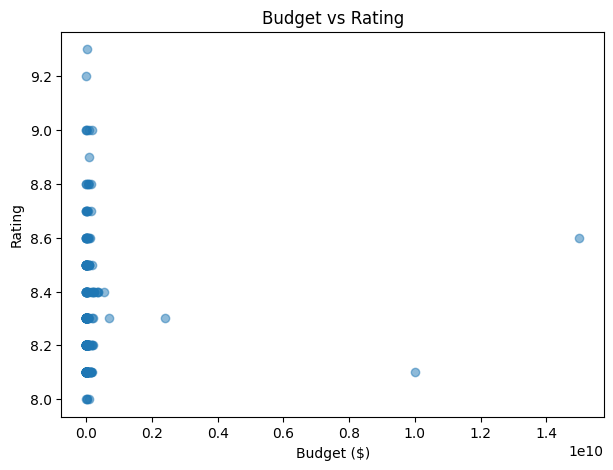

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df_clean["Budget"], df_clean["Rating"], alpha=0.5)
plt.xlabel("Budget ($)")
plt.ylabel("Rating")
plt.title("Budget vs Rating")
plt.savefig("viz4_budget_vs_rating.png", dpi=300)
plt.show()

### Visualization 5: Average Rating by Country


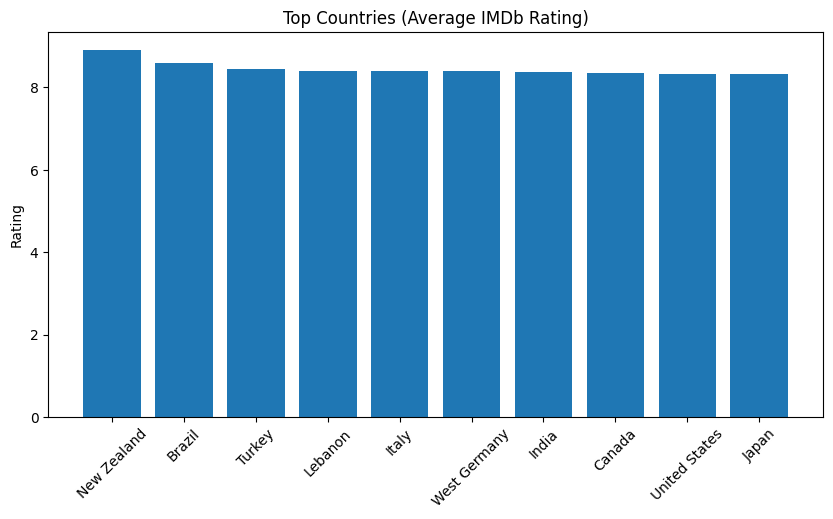

Country
New Zealand      8.900000
Brazil           8.600000
Turkey           8.450000
Lebanon          8.400000
Italy            8.400000
West Germany     8.400000
India            8.366667
Canada           8.350000
United States    8.320134
Japan            8.320000
Name: Rating, dtype: float64

In [10]:
avg_country = df_clean.groupby("Country")["Rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(avg_country.index, avg_country.values)
plt.xticks(rotation=45)
plt.ylabel("Rating")
plt.title("Top Countries (Average IMDb Rating)")
plt.savefig("viz5_top_countries.png", dpi=300)
plt.show()

avg_country



### Visualization 6: Most Common Directors in High-Rated Genre

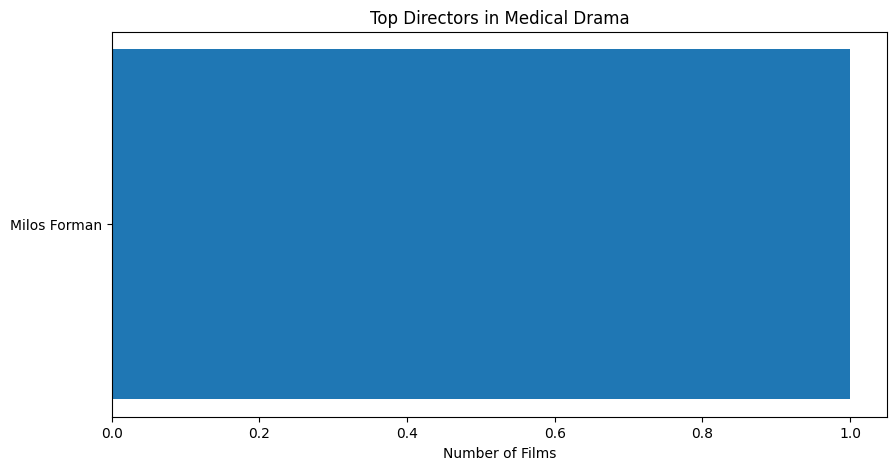

Director
Milos Forman    1
Name: count, dtype: int64

In [11]:
top_genre = avg_rating.index[0]
top_directors = df_clean[df_clean["primary_genre"] == top_genre]["Director"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_directors.index, top_directors.values)
plt.xlabel("Number of Films")
plt.title(f"Top Directors in {top_genre}")
plt.savefig("viz6_top_directors.png", dpi=300)
plt.show()

top_directors

### Visualization 7: Ratings Over Time (Trend)



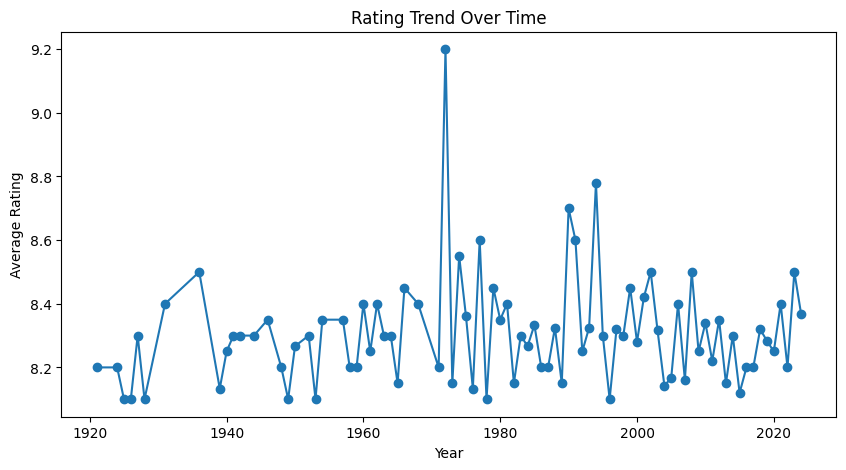

In [12]:
ratings_year = df_clean.groupby("Year")["Rating"].mean()

plt.figure(figsize=(10,5))
plt.plot(ratings_year.index, ratings_year.values, marker="o")
plt.ylabel("Average Rating")
plt.xlabel("Year")
plt.title("Rating Trend Over Time")
plt.savefig("viz7_rating_over_time.png", dpi=300)
plt.show()

###  Visualization 8: Rating Distribution Within Top Genres (Boxplot)

C:\Users\ivaik\AppData\Local\Temp\ipykernel_1296\434589757.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top10, showfliers=False)


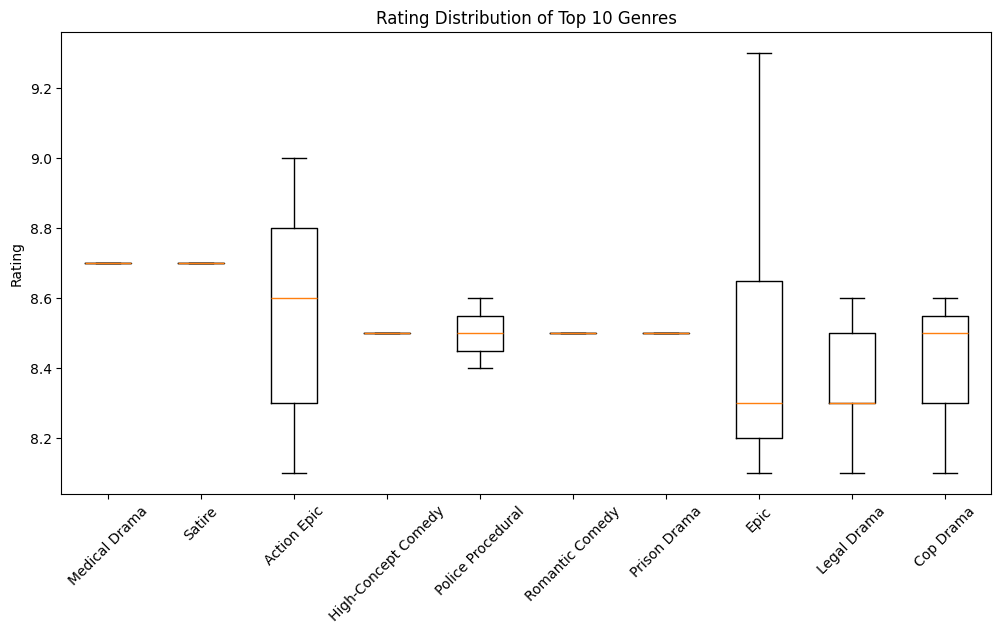

In [14]:
top10 = avg_rating.index[:10]
subset = df_clean[df_clean["primary_genre"].isin(top10)]

data = [subset[subset["primary_genre"] == g]["Rating"] for g in top10]

plt.figure(figsize=(12,6))
plt.boxplot(data, labels=top10, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel("Rating")
plt.title("Rating Distribution of Top 10 Genres")
plt.savefig("viz8_boxplot_genres.png", dpi=300)
plt.show()

## Final Conclusion

The analysis shows that Medical Drama and Satire are the highest-rated genres in the dataset, with average IMDb scores above 8.7. These genres appear less frequently than others, yet they consistently maintain strong critical and audience approval, which is reflected in their low rating variance.

Their success is primarily linked to meaningful storytelling. Films in these genres tend to focus on psychological conflict, ethical dilemmas, and social issues, which create a deeper emotional impact and result in higher viewer evaluation. The data also demonstrates that high ratings are not dependent on large budgets, as there is no clear correlation between production cost and audience reception.

Another contributing factor is the influence of skilled directors. For example, Milos Forman’s presence in the Medical Drama category illustrates how experienced filmmakers can elevate genre quality. Finally, the highest ratings are not limited to films from major industries: countries with smaller markets also produce successful films, showing that strong storytelling can come from any region.

### Conclusion
Genres with the highest IMDb ratings succeed mainly because of narrative depth and consistent artistic quality rather than large budgets or production scale. Their strength lies in impactful themes and thoughtful filmmaking, which lead to greater audience appreciation.

